# # Decision Tree (ID3) Classification
This notebook demonstrates building a Decision Tree using the ID3 algorithm.
Dataset: ID3.csv

## 1.Imports and Load Dataset

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ID3.csv")
X = df.drop(["Day", "Play"], axis=1)
y = df["Play"]

## 2.Entropy Calculation

In [8]:
def entropy(col):
    values, counts = np.unique(col, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs)) if len(probs) > 1 else 0.0

dataset_entropy = round(entropy(y), 4)
print("Entropy of entire dataset =", dataset_entropy)

Entropy of entire dataset = 0.9403


## 3.Information Gain Calculation for Features

In [9]:
information_gains = {}
for feature in X.columns:
    weighted_entropy = 0
    for val in X[feature].unique():
        subset = df[df[feature] == val]
        weighted_entropy += (len(subset)/len(df)) * entropy(subset["Play"])
    ig = round(dataset_entropy - weighted_entropy, 4)
    information_gains[feature] = ig
    print(f"Feature: {feature}, Information Gain: {ig}")

root_feature = max(information_gains, key=information_gains.get)
print("\nSelected Splitting Feature (Max IG) =", root_feature)

Feature: Outlook, Information Gain: 0.2468
Feature: Temperature, Information Gain: 0.0292
Feature: Humidity, Information Gain: 0.1518
Feature: Wind, Information Gain: 0.0481

Selected Splitting Feature (Max IG) = Outlook


## 4.Building Decision Tree Recursively

In [10]:
def build_tree(subset, features):
    classes = subset["Play"].unique()
    if len(classes) == 1:
        return {"label": classes[0]}
    if not features:
        return {"label": subset["Play"].mode()[0]}
    subset_entropy = entropy(subset["Play"])
    igs = {}
    for feature in features:
        weighted_entropy = 0
        for val in subset[feature].unique():
            sub_sub = subset[subset[feature] == val]
            weighted_entropy += (len(sub_sub)/len(subset)) * entropy(sub_sub["Play"])
        igs[feature] = subset_entropy - weighted_entropy
    best = max(igs, key=igs.get)
    tree = {"feature": best, "branches": {}}
    remaining = [f for f in features if f != best]
    for val in subset[best].unique():
        sub_sub = subset[subset[best] == val]
        tree["branches"][val] = build_tree(sub_sub, remaining)
    return tree

tree = build_tree(df, list(X.columns))

## 5.Visualize Decision Tree

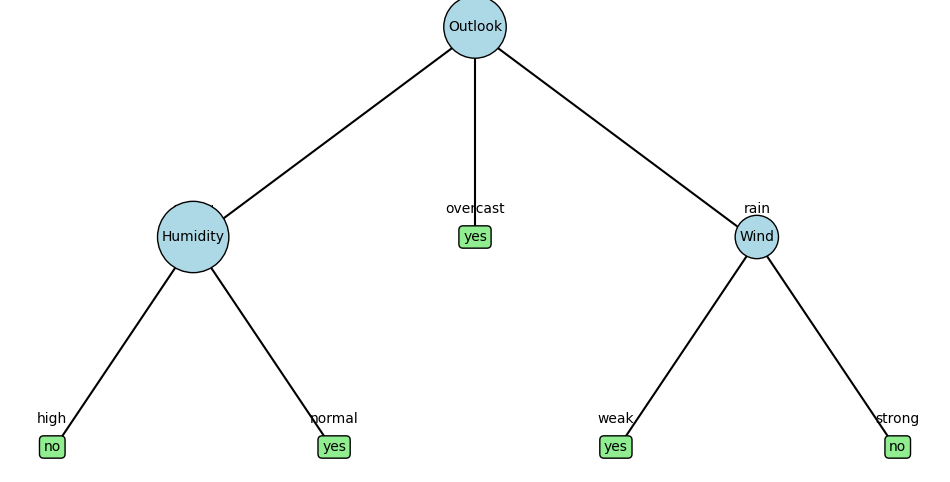

In [11]:
def plot_tree(tree, x=0.5, y=1.0, dx=0.25, parent=None, ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(12,6))
        ax.axis('off')
    if "label" in tree:
        ax.text(x, y, f"{tree['label']}", ha='center', bbox=dict(facecolor='lightgreen', boxstyle='round'))
        if parent:
            ax.plot([parent[0], x], [parent[1], y], 'k-')
        return ax
    ax.text(x, y, f"{tree['feature']}", ha='center', bbox=dict(facecolor='lightblue', boxstyle='circle'))
    if parent:
        ax.plot([parent[0], x], [parent[1], y], 'k-')
    n = len(tree["branches"])
    i = 0
    for val, subtree in tree["branches"].items():
        new_x = x - dx + i*(2*dx/(n-1)) if n>1 else x
        new_y = y - 0.15
        ax.text(new_x, new_y+0.02, f"{val}", ha='center')
        plot_tree(subtree, x=new_x, y=new_y, dx=dx/2, parent=(x,y), ax=ax)
        i += 1
    return ax

ax = plot_tree(tree)
plt.show()